# Exploratory Data Analysis — UCSD Book Graph

**Project:** *What 15 Million Readers Reveal About the Human Condition*  
**Course:** COM-480 Data Visualization (EPFL) — Milestone 1

This notebook produces the evidence behind every claim in the EDA section of our report.  
Each section header maps directly to a paragraph in the report.

---

## 0. Setup

In [2]:
import os, json, gzip, gc, warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14, "axes.labelsize": 12})

DATA_DIR = Path("data")

BOOKS_FILE        = DATA_DIR / "goodreads_books.json.gz"
INTERACTIONS_FILE = DATA_DIR / "goodreads_interactions.csv"
REVIEWS_FILE      = DATA_DIR / "goodreads_reviews_dedup.json.gz"
GENRES_FILE       = DATA_DIR / "goodreads_book_genres_initial.json.gz"

for label, path in [("Books", BOOKS_FILE), ("Interactions", INTERACTIONS_FILE),
                     ("Reviews", REVIEWS_FILE), ("Genres", GENRES_FILE)]:
    status = "\u2713" if path.exists() else "\u2717 MISSING"
    print(f"  {status}  {label}: {path.name}")

def load_gz_jsonl(path, max_records=None, usecols=None):
    """Load gzipped JSON-lines into a DataFrame."""
    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_records is not None and i >= max_records:
                break
            rec = json.loads(line)
            if usecols:
                rec = {k: rec.get(k) for k in usecols}
            records.append(rec)
    return pd.DataFrame(records)

  ✓  Books: goodreads_books.json.gz
  ✓  Interactions: goodreads_interactions.csv
  ✓  Reviews: goodreads_reviews_dedup.json.gz
  ✓  Genres: goodreads_book_genres_initial.json.gz


## 1. Scale

**Report claim:** *"The complete dataset contains 2,360,655 books, 228,648,342 user–book interactions (from 876,145 users), and 15,739,967 detailed reviews with full text. Of the interactions, 112.3M are confirmed reads and 104.7M include a numerical rating."*

Books and reviews are counted by line; interactions are verified in the single-pass scan (Section 1c).

### 1a. Book count

In [3]:
print("Counting books ...")
n_books = 0
with gzip.open(BOOKS_FILE, "rt", encoding="utf-8") as f:
    for line in f:
        n_books += 1

print(f"Total books: {n_books:,}")

Counting books ...
Total books: 2,360,655


### 1b. Review count

In [4]:
print("Counting reviews ...")
n_reviews = 0
with gzip.open(REVIEWS_FILE, "rt", encoding="utf-8") as f:
    for line in f:
        n_reviews += 1

print(f"Total reviews: {n_reviews:,}")

Counting reviews ...
Total reviews: 15,739,967


### 1c. Single-pass scan of all interactions

The interactions CSV (~4 GB, 229M rows) is the most expensive file to read.  
We scan it **once** and collect everything we need for Sections 1, 2, 3, and 5:

- **Section 1 (Scale):** total rows, reads, ratings, unique users
- **Section 2 (Ratings):** exact per-star counts
- **Section 3 (Genres):** interactions per genre
- **Section 5 (User activity):** per-user interaction and rating counts

**Step 1:** Load genre mapping (book_id to primary genre) before the scan.

In [5]:
print("Loading genre mapping ...")
book_to_genre = {}
genre_book_counts = Counter()

with gzip.open(GENRES_FILE, "rt", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        genres = rec.get("genres", {})
        if genres:
            primary = max(genres, key=genres.get)
            book_to_genre[str(rec["book_id"])] = primary
            for g in genres:
                genre_book_counts[g] += 1

print(f"Genre mapping: {len(book_to_genre):,} books assigned a primary genre")
print(f"Unique genre tags: {len(genre_book_counts):,}")

Loading genre mapping ...
Genre mapping: 1,951,142 books assigned a primary genre
Unique genre tags: 10


**Step 2:** Scan full interactions CSV — one pass, all accumulators.

In [6]:
CHUNK = 5_000_000

total_rows = 0
total_read = 0
total_rated = 0
unique_users = set()
rating_counter = Counter()
genre_interaction_counts = Counter()
user_n_interactions = Counter()
user_n_rated = Counter()

print("Scanning full interactions CSV (single pass) ...")
for i, chunk in enumerate(pd.read_csv(INTERACTIONS_FILE, chunksize=CHUNK)):
    total_rows += len(chunk)
    total_read += (chunk["is_read"] == 1).sum()

    rated = chunk[chunk["rating"] > 0]
    total_rated += len(rated)
    for val, cnt in rated["rating"].value_counts().items():
        rating_counter[val] += cnt

    unique_users.update(chunk["user_id"].unique())

    chunk_genres = chunk["book_id"].astype(str).map(book_to_genre)
    for g, cnt in chunk_genres.dropna().value_counts().items():
        genre_interaction_counts[g] += cnt

    for uid, cnt in chunk["user_id"].value_counts().items():
        user_n_interactions[uid] += cnt
    for uid, cnt in rated["user_id"].value_counts().items():
        user_n_rated[uid] += cnt

    if (i + 1) % 10 == 0:
        print(f"  {total_rows / 1e6:.0f}M rows ...")

print(f"\n--- Scan complete ---")
print(f"  Total interactions: {total_rows:>15,}")
print(f"  Confirmed reads:    {total_read:>15,}")
print(f"  With rating (1-5):  {total_rated:>15,}")
print(f"  Unique users:       {len(unique_users):>15,}")

Scanning full interactions CSV (single pass) ...
  50M rows ...
  100M rows ...
  150M rows ...
  200M rows ...

--- Scan complete ---
  Total interactions:     228,648,342
  Confirmed reads:        112,131,203
  With rating (1-5):      104,551,549
  Unique users:               876,145


## 2. Rating Distribution

**Report claim:** *"Ratings skew positive: 4-star and 5-star ratings together account for the majority of all scores. The overall mean rating is approximately 3.94."*

Uses exact `rating_counter` from the single-pass scan.

In [7]:
rating_series = pd.Series(rating_counter).sort_index()

weighted_sum = sum(r * c for r, c in rating_counter.items())
mean_rating = weighted_sum / total_rated

high_ratings = sum(c for r, c in rating_counter.items() if r >= 4)
high_pct = high_ratings / total_rated

print(f"Exact mean rating: {mean_rating:.4f}")
print(f"4-star + 5-star share: {high_pct:.1%}  ({high_ratings:,} / {total_rated:,})")
print(f"\nFull breakdown:")
for r in sorted(rating_counter):
    c = rating_counter[r]
    print(f"  {r} stars:  {c:>12,}   ({c/total_rated:>5.1%})")

Exact mean rating: 3.9394
4-star + 5-star share: 69.8%  (73,003,617 / 104,551,549)

Full breakdown:
  1 stars:     2,050,529   ( 2.0%)
  2 stars:     6,189,946   ( 5.9%)
  3 stars:    23,307,457   (22.3%)
  4 stars:    37,497,451   (35.9%)
  5 stars:    35,506,166   (34.0%)


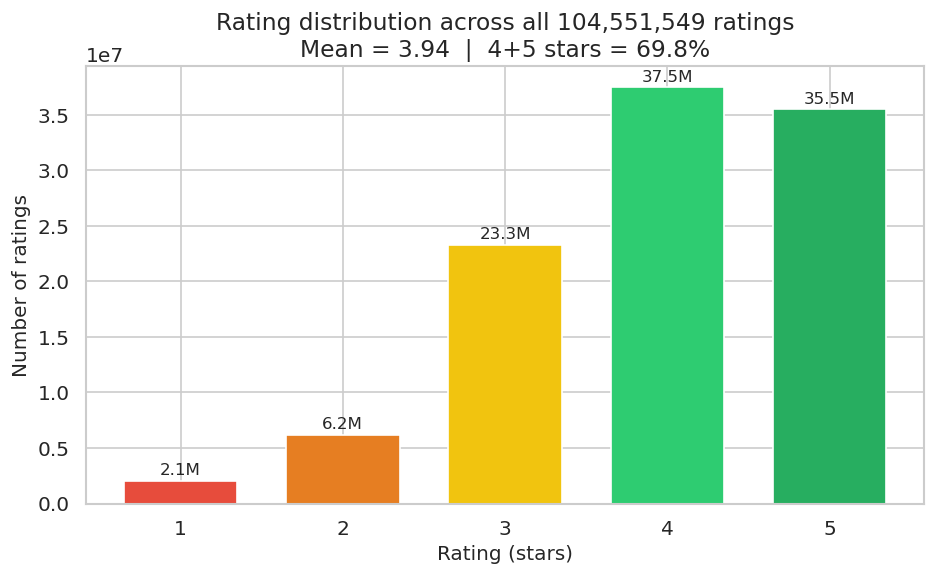

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#27AE60"]
bars = ax.bar(rating_series.index, rating_series.values,
              color=colors[:len(rating_series)], edgecolor="white", width=0.7)
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of ratings")
ax.set_title(f"Rating distribution across all {total_rated:,} ratings\n"
             f"Mean = {mean_rating:.2f}  |  4+5 stars = {high_pct:.1%}")
ax.set_xticks([1, 2, 3, 4, 5])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + total_rated*0.005,
            f"{h/1e6:.1f}M", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Genre Coverage

**Report claim:** *"Romance (658,719 books and 2,077,188 interactions) and Fantasy & Paranormal (538,311 books and 6,130,908 interactions) dominate, while Poetry (88,630 books and 2,660,127 interactions) is far smaller."*

Uses `genre_book_counts` (from genre file) and `genre_interaction_counts` (from the single-pass scan).

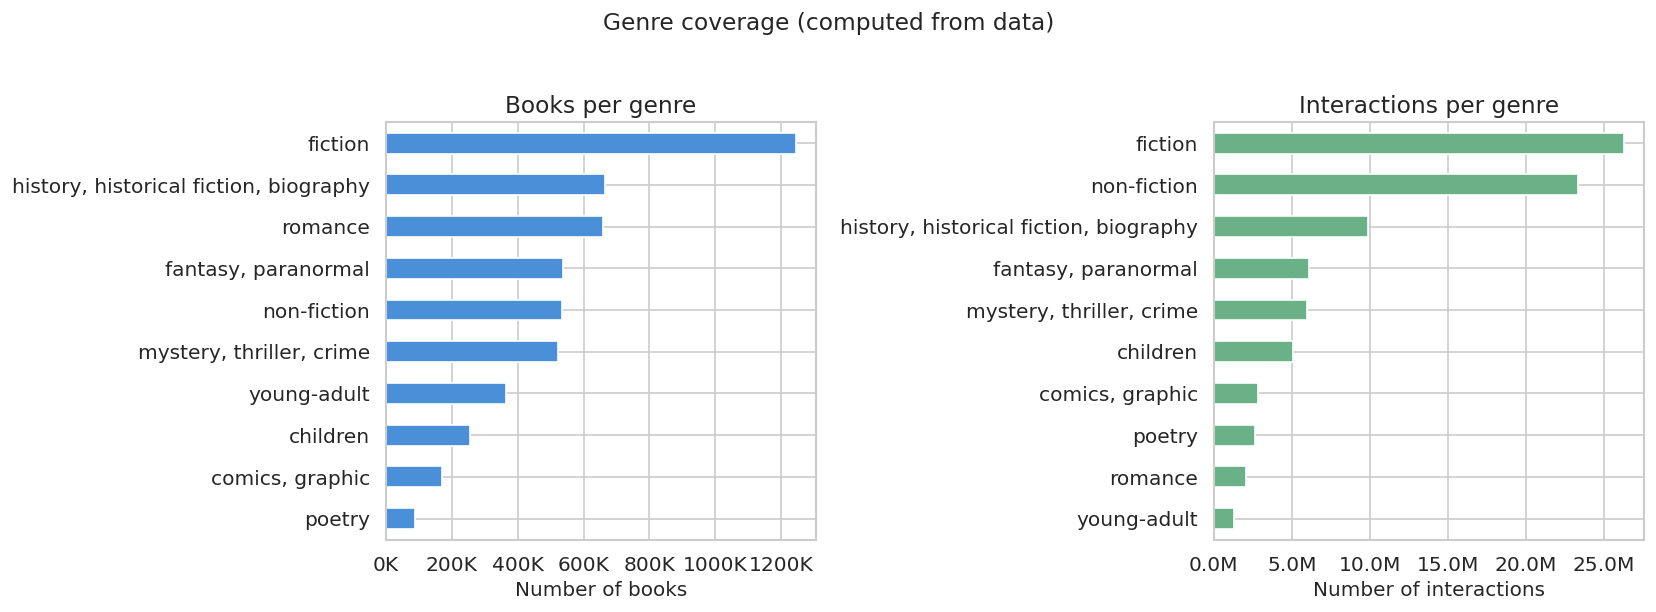

Top genres:
  fiction                         1,244,112 books    26,298,533 interactions
  non-fiction                       533,491 books    23,346,259 interactions
  history, historical fiction, biography    663,795 books     9,891,053 interactions
  fantasy, paranormal               538,311 books     6,130,908 interactions
  mystery, thriller, crime          523,156 books     5,962,912 interactions
  children                          256,935 books     5,048,130 interactions
  comics, graphic                   171,279 books     2,805,460 interactions
  poetry                             88,630 books     2,660,127 interactions
  romance                           658,719 books     2,077,188 interactions
  young-adult                       364,114 books     1,318,102 interactions

Largest:  fiction (26,298,533)
Smallest (top 12): young-adult (1,318,102)
Ratio: 20.0x


In [9]:
top_genres = [
    g for g, _ in sorted(genre_interaction_counts.items(),
                         key=lambda x: x[1], reverse=True)[:12]
]

gdf = pd.DataFrame({
    "books": {g: genre_book_counts.get(g, 0) for g in top_genres},
    "interactions": {g: genre_interaction_counts[g] for g in top_genres},
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf["books"].sort_values().plot.barh(ax=axes[0], color="#4A90D9", edgecolor="white")
axes[0].set_xlabel("Number of books")
axes[0].set_title("Books per genre")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

gdf["interactions"].sort_values().plot.barh(ax=axes[1], color="#6AB187", edgecolor="white")
axes[1].set_xlabel("Number of interactions")
axes[1].set_title("Interactions per genre")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("Genre coverage (computed from data)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig_genre_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top genres:")
for g in top_genres:
    print(f"  {g:<30} {genre_book_counts.get(g,0):>10,} books  "
          f"{genre_interaction_counts[g]:>12,} interactions")

biggest = top_genres[0]
smallest = top_genres[-1]
ratio = genre_interaction_counts[biggest] / genre_interaction_counts[smallest]
print(f"\nLargest:  {biggest} ({genre_interaction_counts[biggest]:,})")
print(f"Smallest (top 12): {smallest} ({genre_interaction_counts[smallest]:,})")
print(f"Ratio: {ratio:.1f}x")

## 4. Temporal Span

**Report claim:** *"Review timestamps range from the early 2000s through late 2017, with review volume growing steeply from ~2007 onward. Data before 2010 is sparse."*

We sample 2M reviews and plot the monthly volume.

Loading 2M reviews for temporal analysis ...


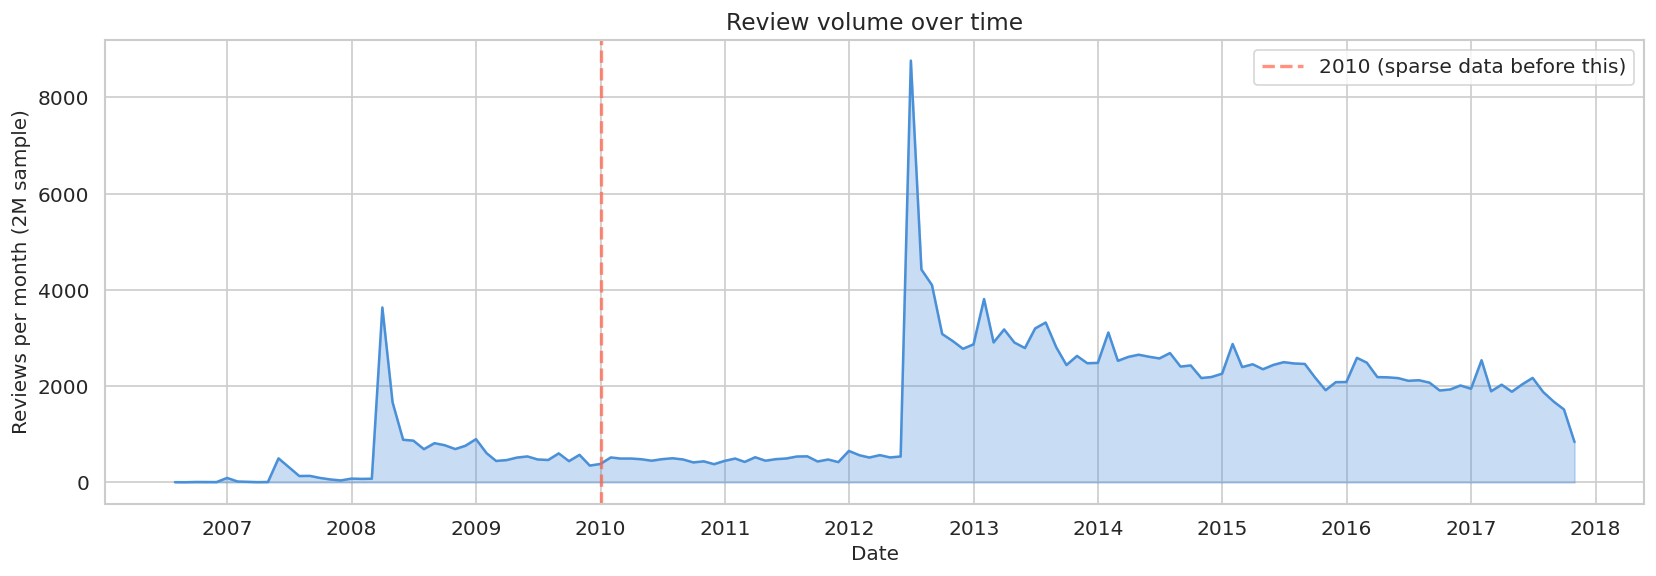

Reviews before 2010: 19,237  (9.6%)
Reviews 2010-2017:   180,763  (90.4%)

Earliest review: 2006-07-04
Latest review:   2017-10-26


In [12]:
print("Loading 2M reviews for temporal analysis ...")
rev_dates = load_gz_jsonl(
    REVIEWS_FILE, max_records=2_000_000,
    usecols=["date_added"]
)
rev_dates["date_added"] = pd.to_datetime(
    rev_dates["date_added"],
    format="%a %b %d %H:%M:%S %z %Y",
    errors="coerce",
    utc=True,
)
rev_dates = rev_dates.dropna(subset=["date_added"])
rev_dates = rev_dates[
    (rev_dates["date_added"].dt.year >= 2000) &
    (rev_dates["date_added"].dt.year <= 2018)
]

monthly = rev_dates.set_index("date_added").resample("ME").size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly.index, monthly.values, alpha=0.3, color="#4A90D9")
ax.plot(monthly.index, monthly.values, color="#4A90D9", lw=1.5)
ax.set_xlabel("Date")
ax.set_ylabel("Reviews per month (2M sample)")
ax.set_title("Review volume over time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

ax.axvline(pd.Timestamp("2010-01"), color="tomato", ls="--", lw=2, alpha=0.7,
           label="2010 (sparse data before this)")
ax.legend()

plt.tight_layout()
plt.savefig("fig_temporal_span.png", dpi=150, bbox_inches="tight")
plt.show()

before_2010 = monthly.loc[:"2009-12"].sum()
after_2010 = monthly.loc["2010-01":].sum()
print(f"Reviews before 2010: {before_2010:,}  ({before_2010/(before_2010+after_2010):.1%})")
print(f"Reviews 2010-2017:   {after_2010:,}  ({after_2010/(before_2010+after_2010):.1%})")
print(f"\nEarliest review: {rev_dates["date_added"].min().date()}")
print(f"Latest review:   {rev_dates["date_added"].max().date()}")

del rev_dates
gc.collect();

## 5. User Activity

**Report claim:** *"Activity follows a heavy-tailed distribution: a small fraction of power users generate a disproportionate share of ratings. For longitudinal analyses like rating drift, we focus on users with at least 30 rated books."*

Uses per-user counters from the single-pass scan — **exact** values across all 229M rows.

In [13]:
user_activity = pd.DataFrame({
    "n_interactions": pd.Series(user_n_interactions),
    "n_rated": pd.Series(user_n_rated),
}).fillna(0).astype(int)

print(f"Total users: {len(user_activity):,}")
print(f"\nActivity percentiles (interactions per user):")
for p in [50, 75, 90, 95, 99]:
    v = user_activity["n_interactions"].quantile(p / 100)
    print(f"  {p}th percentile: {v:.0f}")

Total users: 876,145

Activity percentiles (interactions per user):
  50th percentile: 100
  75th percentile: 265
  90th percentile: 601
  95th percentile: 960
  99th percentile: 2370


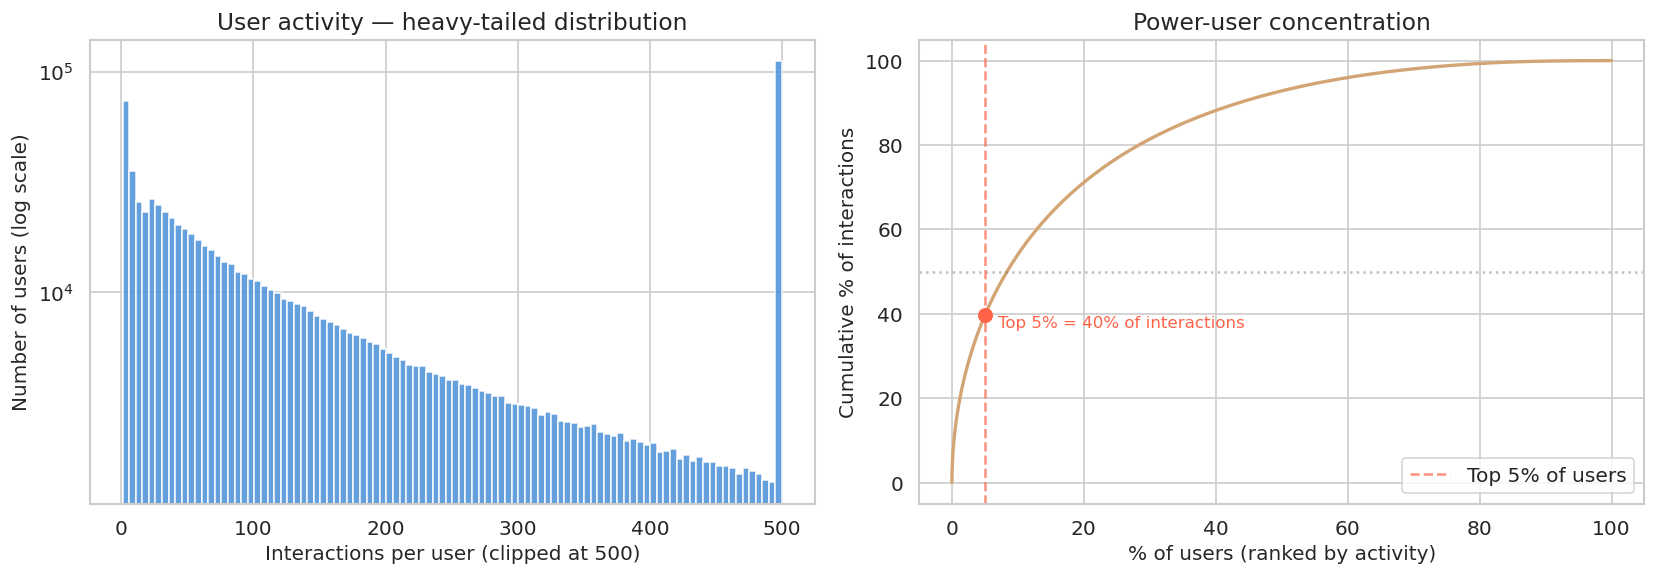


Users with >= 30 ratings (drift-eligible): 547,662 / 876,145 (62.5%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(user_activity["n_interactions"].clip(upper=500),
        bins=100, color="#4A90D9", edgecolor="white", alpha=0.85)
ax.set_xlabel("Interactions per user (clipped at 500)")
ax.set_ylabel("Number of users (log scale)")
ax.set_title("User activity — heavy-tailed distribution")
ax.set_yscale("log")

ax = axes[1]
sorted_act = user_activity["n_interactions"].sort_values(ascending=False).values
cumulative = np.cumsum(sorted_act) / sorted_act.sum()
user_pct = np.arange(1, len(cumulative) + 1) / len(cumulative) * 100
ax.plot(user_pct, cumulative * 100, color="#D4A574", lw=2)
ax.axhline(50, color="gray", ls=":", alpha=0.5)
ax.axvline(5, color="tomato", ls="--", alpha=0.7, label="Top 5% of users")
top5_idx = int(len(cumulative) * 0.05)
top5_share = cumulative[top5_idx] * 100
ax.plot(5, top5_share, "o", color="tomato", markersize=8)
ax.text(7, top5_share - 3, f"Top 5% = {top5_share:.0f}% of interactions",
        color="tomato", fontsize=10)
ax.set_xlabel("% of users (ranked by activity)")
ax.set_ylabel("Cumulative % of interactions")
ax.set_title("Power-user concentration")
ax.legend()

plt.tight_layout()
plt.savefig("fig_user_activity.png", dpi=150, bbox_inches="tight")
plt.show()

n_drift = (user_activity["n_rated"] >= 30).sum()
print(f"\nUsers with >= 30 ratings (drift-eligible): "
      f"{n_drift:,} / {len(user_activity):,} ({n_drift/len(user_activity):.1%})")

## 6. Preprocessing

**Report claim:** *"Parsed full book metadata (2.36M records) with type coercion and year validation. Built a consolidated genre taxonomy from shelf-derived tags. Profiled missing values (publication year, page count, language code)."*

### 6a. Book metadata: type coercion, year validation, missing values

In [15]:
print("Loading full book metadata ...")
books = load_gz_jsonl(
    BOOKS_FILE,
    usecols=["book_id", "title", "language_code", "average_rating",
             "ratings_count", "num_pages", "publication_year"]
)

for col in ["average_rating", "ratings_count", "num_pages", "publication_year"]:
    books[col] = pd.to_numeric(books[col], errors="coerce")

print(f"Loaded {len(books):,} books")

bad_years = (
    books["publication_year"].isna() |
    (books["publication_year"] < 1000) |
    (books["publication_year"] > 2025)
)
n_bad = (bad_years & books["publication_year"].notna()).sum()
books.loc[bad_years & books["publication_year"].notna(), "publication_year"] = np.nan
print(f"Implausible years reset to NaN: {n_bad:,}")

fields = ["publication_year", "num_pages", "language_code"]
print(f"\nMissing values:")
for field in fields:
    n_miss = books[field].isna().sum()
    print(f"  {field:<20} {n_miss:>10,} / {len(books):,}  ({n_miss/len(books):.1%})")

Loading full book metadata ...
Loaded 2,360,655 books
Implausible years reset to NaN: 1,240

Missing values:
  publication_year        600,865 / 2,360,655  (25.5%)
  num_pages               764,133 / 2,360,655  (32.4%)
  language_code                 0 / 2,360,655  (0.0%)


### 6b. Genre taxonomy from shelf-derived tags

In [16]:
print(f"Total unique genre tags: {len(genre_book_counts):,}")

print(f"\nTop 20 genre tags (by number of books):")
for g, c in genre_book_counts.most_common(20):
    print(f"  {g:<30} {c:>10,}")

tags_over_1000 = sum(1 for c in genre_book_counts.values() if c >= 1000)
tags_under_100 = sum(1 for c in genre_book_counts.values() if c < 100)
print(f"\nTags with >= 1000 books: {tags_over_1000}")
print(f"Tags with < 100 books:   {tags_under_100} (long tail, needs consolidation)")

Total unique genre tags: 10

Top 20 genre tags (by number of books):
  fiction                         1,244,112
  history, historical fiction, biography    663,795
  romance                           658,719
  fantasy, paranormal               538,311
  non-fiction                       533,491
  mystery, thriller, crime          523,156
  young-adult                       364,114
  children                          256,935
  comics, graphic                   171,279
  poetry                             88,630

Tags with >= 1000 books: 10
Tags with < 100 books:   0 (long tail, needs consolidation)
